<a href="https://colab.research.google.com/github/walji123/e-commerce-data-analysis/blob/main/Python_Project_3_E_commerce_dataset_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

# 1. Load the dataset
df = pd.read_csv('/content/drive/MyDrive/python_projects/realistic_e_commerce_sales_data.csv')

# 2. Display first 5, last 5, and random 5 rows
display(df.head())
display(df.tail())
display(df.sample(5))

# 3. Column names, summary, data types, and missing values
df.info()

,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
0,CUST0268,Male,North,NaN,Monitor,Electronics,300.0,5,1500,13.31,Returned,2023-12-08
1,CUST0046,Male,West,22.0,Headphones,Accessories,100.0,2,200,6.93,In Transit,2023-04-09
2,CUST0169,Female,South,54.0,Monitor,Electronics,300.0,1,300,11.31,Returned,2023-08-28
3,CUST0002,Male,North,23.0,Headphones,Accessories,100.0,5,500,12.22,Delivered,2023-01-18
4,CUST0173,Female,South,NaN,Laptop,Electronics,1500.0,3,4500,5.40,Delivered,2023-01-19


,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
995,CUST0201,Female,South,49.0,Headphones,Accessories,100.0,1,100,17.21,In Transit,2023-01-05
996,CUST0133,Male,East,47.0,Laptop,Electronics,1500.0,1,1500,19.19,Delivered,2023-04-01
997,CUST0055,Female,North,NaN,Mouse,Accessories,30.0,5,150,19.35,Delivered,2023-10-20
998,CUST0023,Female,South,29.0,Laptop,Electronics,1500.0,5,7500,10.36,Returned,2023-01-07
999,CUST0040,Male,NaN,29.0,Smartwatch,Wearables,200.0,1,200,7.53,Delivered,2023-01-30


,Customer ID,Gender,Region,Age,Product Name,Category,Unit Price,Quantity,Total Price,Shipping Fee,Shipping Status,Order Date
9,CUST0023,Male,West,29.0,Headphones,Accessories,100.0,3,300,10.70,Delivered,2023-04-23
660,CUST0058,Female,North,42.0,Mouse,Accessories,30.0,5,150,8.28,Returned,2023-11-14
574,CUST0063,Male,North,20.0,Smartwatch,Wearables,200.0,4,800,15.78,Delivered,2023-06-14
245,CUST0155,Male,West,41.0,Headphones,Accessories,100.0,3,300,11.98,Delivered,2023-06-12
163,CUST0045,Female,East,21.0,Smartphone,Electronics,800.0,3,2400,15.78,Delivered,2023-11-07


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Customer ID      1000 non-null   object 
 1   Gender           1000 non-null   object 
 2   Region           950 non-null    object 
 3   Age              900 non-null    float64
 4   Product Name     1000 non-null   object 
 5   Category         1000 non-null   object 
 6   Unit Price       1000 non-null   float64
 7   Quantity         1000 non-null   int64  
 8   Total Price      1000 non-null   int64  
 9   Shipping Fee     1000 non-null   float64
 10  Shipping Status  950 non-null    object 
 11  Order Date       1000 non-null   object 
dtypes: float64(3), int64(2), object(7)
memory usage: 93.9+ KB


In [ ]:
display(df.shape)
display(df.dtypes)

(1000, 12)

,0
Customer ID,object
Gender,object
Region,object
Age,float64
Product Name,object
Category,object
Unit Price,float64
Quantity,int64
Total Price,int64
Shipping Fee,float64


##**Task 2: Basic Structure Inspection**

**There are 1000 rows and 12 columns in the Dataset**

**The data types of represented by each column are: 'Customer ID': object; 'Gender': object; 'Region': object; 'Age': float64; 'Product Name': object; 'Category': object, 'Unit Price': float64; 'Quantity': int64; 'Total Price': int64; 'Shipping Fee': float64; 'Shipping Status': object; and 'Order Date': object**

In [ ]:
df.isnull().sum()

,0
Customer ID,0
Gender,0
Region,50
Age,100
Product Name,0
Category,0
Unit Price,0
Quantity,0
Total Price,0
Shipping Fee,0


In [ ]:
# 1. Fill missing numerical values in 'Age' with the median age
df['Age'] = df['Age'].fillna(df['Age'].median())

# 2. Fill missing categorical values with 'Unknown'
df['Region'] = df['Region'].fillna('Unknown')
df['Shipping Status'] = df['Shipping Status'].fillna('Unknown')

# 3. Verify that all missing values are resolved
df.isnull().sum()

,0
Customer ID,0
Gender,0
Region,0
Age,0
Product Name,0
Category,0
Unit Price,0
Quantity,0
Total Price,0
Shipping Fee,0


##**Part 2 — Data Cleaning**

**I chose to fill missing values instead of removing them to preserve analysis integrity. If I remove missing values I may alter the data in a way that causes a problem with my overall analysis and final findings. In this case, it is best to fill the values.**

In [ ]:
df.duplicated().sum()

np.int64(0)

##**Task 4: Duplicate Records**

**No duplicate records exist in this dataset.**

In [ ]:
df['Category'] = df['Category'].str.lower()
df['Region'] = df['Region'].str.strip()

#**Task 5: Standardization**

*   **The first line of code made every value in the 'Category' column into small letters.**
*  **The second line of code removed any accidental leading space or trailing zeroes in the Region column.**



In [ ]:
# Task 6: Revenue Analysis

# 1. Create Revenue metric (Quantity x Unit Price)
df['Revenue'] = df['Quantity'] * df['Unit Price']

# 2. Additional Metric: Average Quantity Per Order
avg_quantity = df['Quantity'].mean()

# View the result
display(df[['Quantity', 'Unit Price', 'Revenue']].head())
print(f"Average Quantity Per Order: {avg_quantity:.2f}")

,Quantity,Unit Price,Revenue
0,5,300.0,1500.0
1,2,100.0,200.0
2,1,300.0,300.0
3,5,100.0,500.0
4,3,1500.0,4500.0


Average Quantity Per Order: 3.01


##**Task 6: Revenue Analysis**

**I created a new metric that displays average quantity per order. This metric is potentially beneficial to see if customers buy single items or multiple products at once or to help me see if cross-selling or bundling works.**





In [ ]:
df[['Quantity', 'Shipping Fee']].describe()

,Quantity,Shipping Fee
count,1000.000000,1000.000000
mean,3.008000,12.416390
std,1.404246,4.412185
min,1.000000,5.000000
25%,2.000000,8.560000
50%,3.000000,12.315000
75%,4.000000,16.075000
max,5.000000,19.980000


**Order sizes range from a minimum of 1 item to a maximum of 5 items.**

**Shipping Fee prices range from a minimum of \$5 to a maximum of \$19.98 across all shipments.**

In [ ]:
df.groupby('Category')[['Revenue', 'Quantity']].sum().sort_values(by='Revenue', ascending=False).style.format({'Revenue': '{:,.2f}'})

,Revenue,Quantity
Category,,
electronics,"1,231,618.17",1409
wearables,"74,200.00",371
accessories,"72,973.04",1228


**The electronic category produces the highest amount of revenue totaling \$1,231,618.**

In [ ]:
df.groupby('Product Name').agg({
    'Total Price': 'sum',
    'Quantity': 'sum',
    'Unit Price': 'mean'
}).sort_values(by='Total Price', ascending=False).head(10).style.format({
    'Total Price': '${:,.2f}',
    'Unit Price': '${:,.2f}'
})

,Total Price,Quantity,Unit Price
Product Name,,,
Laptop,"$696,000.00",464,"$1,541.81"
Smartphone,"$353,600.00",442,$818.14
Monitor,"$150,900.00",503,$308.89
Smartwatch,"$74,200.00",371,$200.00
Headphones,"$37,000.00",370,$101.79
Keyboard,"$22,900.00",458,$50.74
Mouse,"$12,000.00",400,$30.95


**Laptops and Smartphones dominate Total Revenue because their Unit prices are higher than other products.**

In [ ]:
# 1. Calculations
top_customers = df.groupby('Customer ID')['Total Price'].sum().sort_values(ascending=False).head(10)
avg_spend = df.groupby('Customer ID')['Total Price'].sum().mean()
max_purchase = df['Total Price'].max()

# 2. Displaying results
print("--- Top 10 Customers by Spending ---")
display(top_customers)

print(f"\nOverall Average Spend Per Customer: ${avg_spend:,.2f}")
print(f"Highest Individual Purchase: ${max_purchase:,.2f}")

--- Top 10 Customers by Spending ---


,Total Price
Customer ID,
CUST0204,29100
CUST0095,22440
CUST0131,21180
CUST0139,18350
CUST0281,17850
CUST0144,17320
CUST0200,16700
CUST0197,16150
CUST0064,14600



Overall Average Spend Per Customer: $4,611.64
Highest Individual Purchase: $7,500.00


**The average spend per customer is roughly \$4612, while the highest individual spend is \$7,500.**

In [ ]:
# 1. Commonly purchased products (by total quantity)
common_products = df.groupby('Product Name')['Quantity'].sum().sort_values(ascending=False).head(10)

# 2. Categories attracting the most unique customers
category_customers = df.groupby('Category')['Customer ID'].nunique().sort_values(ascending=False)

# 3. Customer group comparison (Pivot Table)
cat_gender_pivot = df.pivot_table(
    index='Category',
    columns='Gender',
    values='Total Price',
    aggfunc='sum',
    fill_value=0,
    margins=True
)

# 4. Display all findings
print("--- Top 7 Most Commonly Purchased Products ---")
display(common_products)

print("\n--- Categories Attracting the Most Unique Customers ---")
display(category_customers)

print("\n--- Total Revenue by Category and Gender ---")
display(cat_gender_pivot)

--- Top 10 Most Commonly Purchased Products ---


,Quantity
Product Name,
Monitor,503
Laptop,464
Keyboard,458
Smartphone,442
Mouse,400
Smartwatch,371
Headphones,370



--- Categories Attracting the Most Unique Customers ---


,Customer ID
Category,
electronics,235
accessories,228
wearables,103



--- Total Revenue by Category and Gender ---


Gender,Female,Male,All
Category,,,
accessories,34610,37290,71900
electronics,564200,636300,1200500
wearables,32200,42000,74200
All,631010,715590,1346600



*   **The most commonly purchased products are monitors totaling a quantity of 503 according to the given data.**
*   **The product category that attracts the most customers is electronics as displayed in the data as attracting 235 customers.**
* **According to the data, men seem to be purchasing more products than women, but potentially not significant to make any changes to current marketing strategies.**



In [ ]:
# 1. Create base summary with count and average revenue
shipping_summary = df.groupby('Shipping Status').agg(
    transaction_count=('Total Price', 'count'),
    average_revenue=('Total Price', 'mean')
)

# 2. Add percentage of total transactions
shipping_summary['percentage'] = (shipping_summary['transaction_count'] / len(df)) * 100

# 3. Display the summary
display(shipping_summary)

,transaction_count,average_revenue,percentage
Shipping Status,,,
Delivered,313,1301.533546,31.3
In Transit,329,1348.206687,32.9
Returned,308,1349.480519,30.8
Unknown,50,1600.400000,5.0


**Over one-third of  revenue is currently tied up in unresolved or returned shipments, primarily driven by high-value items like laptops and smartphones.**

In [ ]:
# 1. Sales and average revenue by Region
region_summary = (
    df.groupby('Region')['Total Price']
    .agg(['sum', 'mean'])
    .round(2)
    .sort_values(by='sum', ascending=False)
)
display(region_summary)

# 2. Top-selling category per Region
category_sales = df.groupby(['Region', 'Category'])['Total Price'].sum().reset_index()
sorted_sales = category_sales.sort_values(by='Total Price', ascending=False)
top_categories = sorted_sales.drop_duplicates(subset=['Region'], keep='first')
display(top_categories)

,sum,mean
Region,,
East,329950,1428.35
North,324990,1419.17
West,323390,1314.59
South,301040,1233.77
Unknown,67230,1344.60


,Region,Category,Total Price
4,North,electronics,294500
13,West,electronics,289700
1,East,electronics,288900
7,South,electronics,266600
10,Unknown,electronics,60800


**As defined in the dataset, the East and North region produced the highest revenue. While when considering electronics, the North and West region produced the highest revenue with \$294,500 and \$289,700 respectively.**

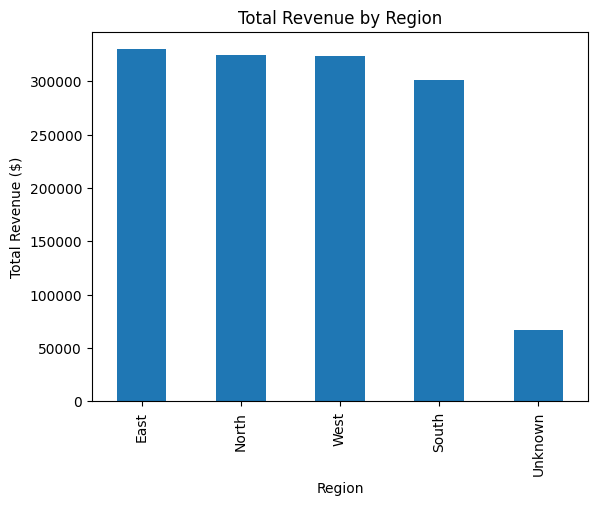

In [ ]:
import matplotlib.pyplot as plt

# 1. Create the bar chart
region_summary['sum'].plot(kind='bar')

# 2. Add title and axis labels (Task 15 requirement!)
plt.title('Total Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Total Revenue ($)')

# 3. Display the plot
plt.show()

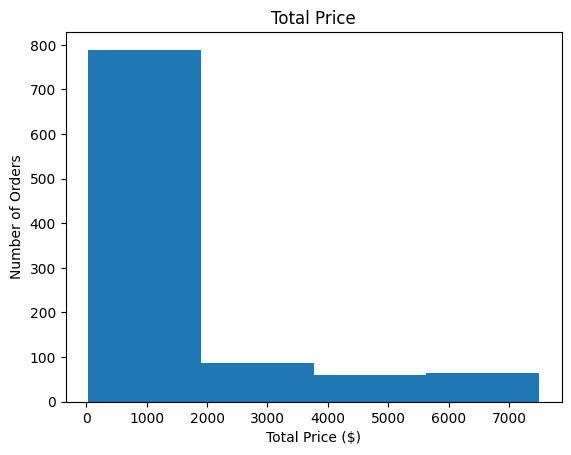

In [ ]:
df['Total Price'].plot(kind='hist', bins = 4)
plt.title('Total Price')
plt.xlabel('Total Price ($)')
plt.ylabel('Number of Orders')
plt.show()

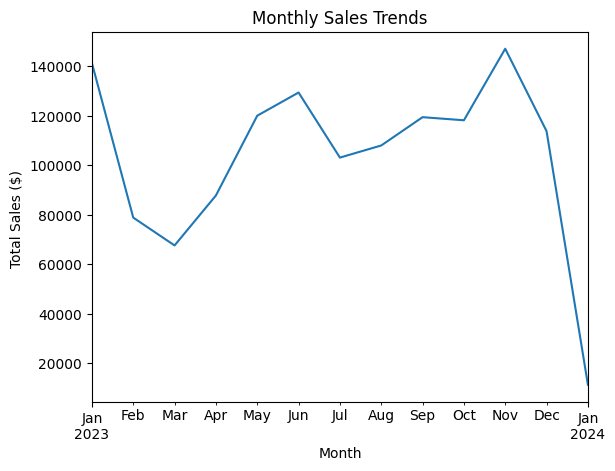

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['month'] = df['Order Date'].dt.to_period('M')
aggregated_series = df.groupby('month')['Total Price'].sum()
aggregated_series.plot(kind='line')
plt.title('Monthly Sales Trends')
plt.xlabel('Month')
plt.ylabel('Total Sales ($) ')
plt.show()

**Peak sales tend to be in November and Decemember possibly because of the holiday season.**

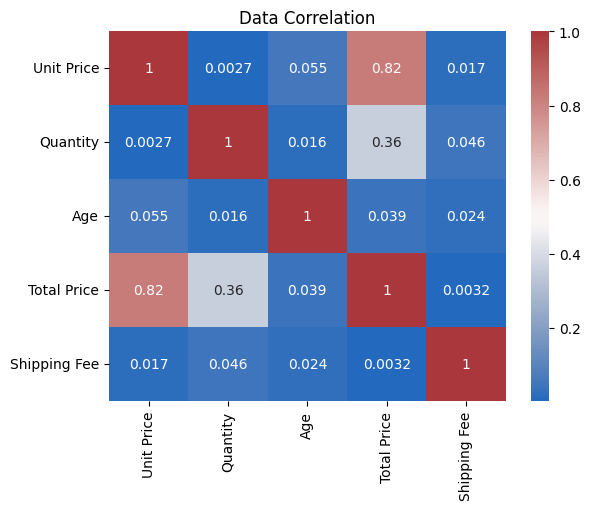

In [ ]:
corr_matrix = df[['Unit Price', 'Quantity', 'Age', 'Total Price', 'Shipping Fee']].corr()
import seaborn as sns
sns.heatmap(corr_matrix, annot=True, cmap='vlag')
plt.title('Data Correlation')
plt.show()

**Total Price is primarily driven by Unit Price (0.82) rather than Quantity (0.36), while Age and Shipping Fee show no meaningful correlation with any variable.**

# **Insights**

1.   Total Price is primarily driven by Unit Price (0.82) rather than Quantity (0.36), while Age and Shipping Fee show no meaningful correlation with any variable.
2.   Peak sales tend to be in November and Decemember possibly because of the holiday season.
3. The electronic category produces the highest amount of revenue totaling $1,231,618.



# **Recommendations**

1. Management and the executive team should consider increasing the unit price of products as the market changes to ensure that consistent revenue is being brought in.
2. The data science team would benefit from more analysis into why Novemeber and December bring in more revenue than other months.
3. Management and the inventory team should ensure that electronics are consistently stocked because they are significant revenue drivers.